# Домашнее задание (RU)

Возьмите датасет на русском. Это может быть датасет из прошлой домашки (новости), или новый, например  
**`data-silence/rus_news_classifier`** (HuggingFace Datasets)

Сделайте аналогичный ноутбук:

1) Один базовый векторайзер (TF‑IDF), логрегрессия (подбор $\alpha$), метрики accuracy и macro‑F1. Подбор гиперпараметров (eta, tol, max_iter). Сделайте необходимую предобработку для "мешка слов" на русском
2) Линейный SVM (подбор C), сравнить метрики.  
3) Добавить L1-регуляризацию и вывести топ‑признаки (слова/n‑граммы) для 2–3 классов.  
4) (Бонус) Попробовать **char n‑grams TF‑IDF** и сравнить с word TF‑IDF.

Сдача: таблица результатов + 3-5 предложений выводов.


In [ ]:
# --- Импорты ---
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, log_loss, ConfusionMatrixDisplay

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

np.random.seed(7)


# Датасет с категориями: https://huggingface.co/datasets/data-silence/rus_news_classifier

Категория: 1 - conflicts, 8 - society

In [ ]:
# --- Загрузка данных ---
from datasets import load_dataset

ds = load_dataset("data-silence/rus_news_classifier")

#  1 - conflicts, 8 - society
text_conflicts = [i["news"] for i in ds["train"] if i["labels"] == 1]
text_society  = [i["news"] for i in ds["train"] if i["labels"] == 8]

X_text = np.array(text_conflicts + text_society, dtype=object)
y = np.array([0]*len(text_conflicts) + [1]*len(text_society))

print("Всего документов:", len(X_text))
print("Баланс классов:", dict(zip(*np.unique(y, return_counts=True))))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/69.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/57530 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14383 [00:00<?, ? examples/s]

Всего документов: 11214
Баланс классов: {np.int64(0): np.int64(6277), np.int64(1): np.int64(4937)}


In [ ]:
# --- split train/val/test ---

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_text, y, test_size=0.30, random_state=7, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=7, stratify=y_tmp
)

print("train:", len(X_train), "val:", len(X_val), "test:", len(X_test))


train: 7849 val: 1682 test: 1683


In [ ]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
ru_stop = stopwords.words("russian")

!pip install pymorphy3

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 39.9 MB/s eta 0:00:00


Сделайте необходимую предобработку для "мешка слов" на русском

In [ ]:
from functools import lru_cache
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")

@lru_cache(maxsize=200_000)
def lemma_cached(w: str) -> str:
    return morph.parse(w)[0].normal_form

def simple_tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(text.lower())

def tokenize_lemmas(text: str) -> list[str]:
    token = []
    words = simple_tokenize(text)
    for w in words:
        if w in ru_stop:
            continue
        lemma = lemma_cached(w)
        if lemma in ru_stop:
            continue
        token.append(lemma)
    return token

In [ ]:
# --- Pipeline: TF-IDF -> Logistic Regression через SGD ---
# SGDClassifier(loss="log_loss") — это логистическая регрессия, обучаемая градиентным спуском.

pipe_sgd_lr = Pipeline([
    ("vec", TfidfVectorizer(
        tokenizer=tokenize_lemmas,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        ngram_range=(1, 2),
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-5,                 # будем подбирать
        learning_rate="constant",
        eta0=0.02,
        max_iter=30,                # эпохи (внутри .fit)
        tol=1e-6,
        random_state=7
    ))
])


alphas = [1e-6, 1e-5, 1e-4]
results = []

for a in alphas:
    model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=a,
            learning_rate="constant",
            eta0=0.02,
            max_iter=30,
            tol=1e-6,
            random_state=7
        ))
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")
    results.append((a, acc, f1))

# выбираем лучший по macro-F1
best_alpha, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (alpha, acc_val, f1_val):")
for a, acc, f1 in results:
    print(f"alpha={a:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")

print("\nЛучший alpha:", best_alpha, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (alpha, acc_val, f1_val):
alpha=1e-06     acc_val=0.907  f1_val=0.905
alpha=1e-05     acc_val=0.907  f1_val=0.905
alpha=0.0001    acc_val=0.907  f1_val=0.905

Лучший alpha: 1e-06 | acc_val: 0.9072532699167658 | f1_val: 0.9047249721137758


In [ ]:
etas = [0.005, 0.01, 0.02, 0.05]
results = []

for eta in etas:
  model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=eta,
            max_iter=30,
            tol=1e-6,
            random_state=7
        ))
    ])
  model.fit(X_train, y_train)
  y_val_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_val_pred)
  f1  = f1_score(y_val, y_val_pred, average="macro")
  results.append((eta, acc, f1))

# выбираем лучший по macro-F1
best_eta, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (eta, acc_val, f1_val):")
for e, acc, f1 in results:
    print(f"eta={e:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")


print("\nЛучший eta:", best_eta, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (eta, acc_val, f1_val):
eta=0.005     acc_val=0.898  f1_val=0.895
eta=0.01      acc_val=0.902  f1_val=0.900
eta=0.02      acc_val=0.907  f1_val=0.905
eta=0.05      acc_val=0.907  f1_val=0.904

Лучший eta: 0.02 | acc_val: 0.9072532699167658 | f1_val: 0.9047249721137758


In [ ]:
tols      = [1e-3, 1e-4, 1e-6]
results = []

for t in tols:
  model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=best_eta,
            max_iter=30,
            tol=t,
            random_state=7
        ))
    ])
  model.fit(X_train, y_train)
  y_val_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_val_pred)
  f1  = f1_score(y_val, y_val_pred, average="macro")
  results.append((t, acc, f1))
 # выбираем лучший по macro-F1
best_tol, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (tol, acc_val, f1_val):")
for t, acc, f1 in results:
    print(f"tol={t:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")


print("\nЛучший tol:", best_tol, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (tol, acc_val, f1_val):
tol=0.001     acc_val=0.907  f1_val=0.905
tol=0.0001    acc_val=0.907  f1_val=0.905
tol=1e-06     acc_val=0.907  f1_val=0.905

Лучший tol: 0.001 | acc_val: 0.9072532699167658 | f1_val: 0.9047249721137758


In [ ]:
max_iters = [15, 30, 50]
results = []

for i in max_iters:
  model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=best_eta,
            max_iter=i,
            tol=best_tol,
            random_state=7
        ))
    ])
  model.fit(X_train, y_train)
  y_val_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_val_pred)
  f1  = f1_score(y_val, y_val_pred, average="macro")
  results.append((i, acc, f1))
best_max_iter, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (tol, acc_val, f1_val):")
for i, acc, f1 in results:
    print(f"best_max_iter={i:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")


print("\nЛучший max_iter:", best_max_iter, "| acc_val:", best_acc, "| f1_val:", best_f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Результаты (tol, acc_val, f1_val):
best_max_iter=15        acc_val=0.902  f1_val=0.900
best_max_iter=30        acc_val=0.907  f1_val=0.905
best_max_iter=50        acc_val=0.910  f1_val=0.907

Лучший max_iter: 50 | acc_val: 0.9096313912009513 | f1_val: 0.9073133098991868


In [ ]:
# --- Финальная модель с best_alpha ---
best_sgd_lr = Pipeline([
    ("vec", TfidfVectorizer(
        tokenizer=tokenize_lemmas,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        max_df=0.9,
        ngram_range=(1, 2),
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=best_alpha,
        learning_rate="constant",
        eta0=best_eta,
        max_iter=best_max_iter,
        tol=best_tol,
        random_state=7
    ))
])
best_sgd_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('vec',
                 TfidfVectorizer(lowercase=False, max_df=0.9, min_df=3,
                                 ngram_range=(1, 2), token_pattern=None,
                                 tokenizer=<function tokenize_lemmas at 0x79c63fe6d620>)),
                ('clf',
                 SGDClassifier(alpha=1e-06, eta0=0.02, learning_rate='constant',
                               loss='log_loss', max_iter=50, random_state=7))])

In [ ]:
# --- Оценка на val/test для лучшей модели ---
y_val_pred = best_sgd_lr.predict(X_val)
y_test_pred = best_sgd_lr.predict(X_test)

print("VAL accuracy:", accuracy_score(y_val, y_val_pred))
print("VAL macro-F1:", f1_score(y_val, y_val_pred, average="macro"))
print()
print("TEST accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST macro-F1:", f1_score(y_test, y_test_pred, average="macro"))
print("\nОтчёт (test):\n", classification_report(y_test, y_test_pred, target_names=["conflicts", "society"]))

acc_test = accuracy_score(y_test, y_test_pred)
f1_test  = f1_score(y_test, y_test_pred, average="macro")
conclusion = []
conclusion.append({
    "Model": "SGD Logistic (Pipeline, L2)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})


VAL accuracy: 0.9096313912009513
VAL macro-F1: 0.9073133098991868

TEST accuracy: 0.8978015448603683
TEST macro-F1: 0.8950812019218223

Отчёт (test):
               precision    recall  f1-score   support

   conflicts       0.88      0.95      0.91       942
     society       0.92      0.84      0.88       741

    accuracy                           0.90      1683
   macro avg       0.90      0.89      0.90      1683
weighted avg       0.90      0.90      0.90      1683



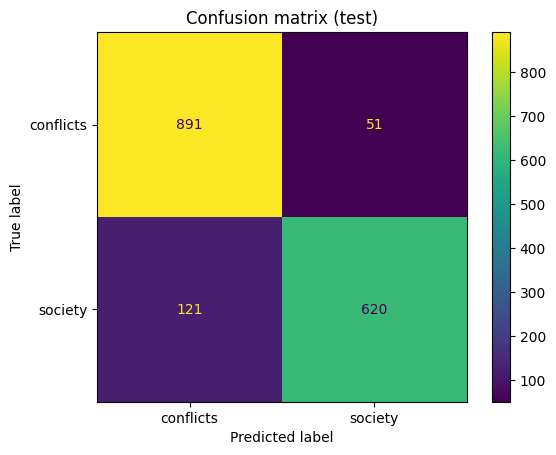

In [ ]:
# --- Confusion matrix (test) ---
disp = ConfusionMatrixDisplay.from_estimator(best_sgd_lr, X_test, y_test, display_labels=["conflicts", "society"])
plt.title("Confusion matrix (test)")
plt.grid(False)
plt.show()


In [ ]:
# --- Подготовка: векторизуем отдельно (чтобы быстро считать loss) ---
print("best_alpha =", best_alpha)

vec = best_sgd_lr.named_steps["vec"]
Xtr = vec.transform(X_train)
Xva = vec.transform(X_val)

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=best_alpha,
    learning_rate="constant",
    eta0=0.02,
    random_state=7
)

classes = np.array([0, 1])


best_alpha = 1e-06


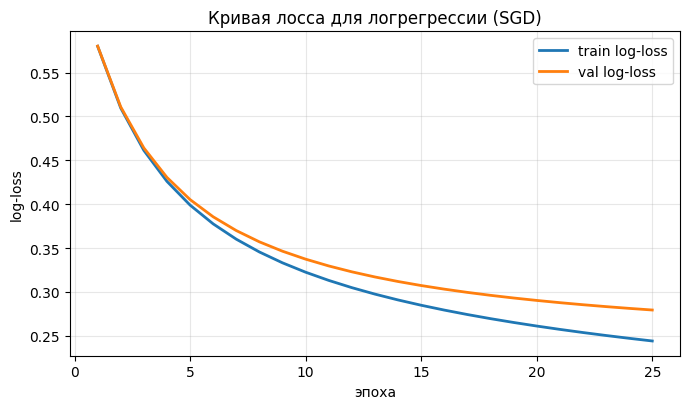

In [ ]:
# --- Обучение по эпохам + логирование log-loss ---
epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    # partial_fit: одна эпоха SGD на всей обучающей матрице
    if epoch == 0:
        sgd.partial_fit(Xtr, y_train, classes=classes)
    else:
        sgd.partial_fit(Xtr, y_train)

    # вероятности нужны для log_loss
    p_tr = sgd.predict_proba(Xtr)
    p_va = sgd.predict_proba(Xva)

    train_losses.append(log_loss(y_train, p_tr))
    val_losses.append(log_loss(y_val, p_va))

plt.figure(figsize=(7, 4.2))
plt.plot(range(1, epochs+1), train_losses, linewidth=2, label="train log-loss")
plt.plot(range(1, epochs+1), val_losses, linewidth=2, label="val log-loss")
plt.xlabel("эпоха")
plt.ylabel("log-loss")
plt.title("Кривая лосса для логрегрессии (SGD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- Accuracy и F1 для SGD-логрегрессии (на val/test) ---
Xte = vec.transform(X_test)

y_val_pred_sgd = sgd.predict(Xva)
y_test_pred_sgd = sgd.predict(Xte)

print("SGD VAL accuracy:", accuracy_score(y_val, y_val_pred_sgd))
print("SGD VAL macro-F1:", f1_score(y_val, y_val_pred_sgd, average="macro"))
print()
print("SGD TEST accuracy:", accuracy_score(y_test, y_test_pred_sgd))
print("SGD TEST macro-F1:", f1_score(y_test, y_test_pred_sgd, average="macro"))

conclusion.append({
    "Model": "SGD Logistic (partial_fit, L2)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})


SGD VAL accuracy: 0.9054696789536266
SGD VAL macro-F1: 0.9027951686540425

SGD TEST accuracy: 0.8983957219251337
SGD TEST macro-F1: 0.89546071235922


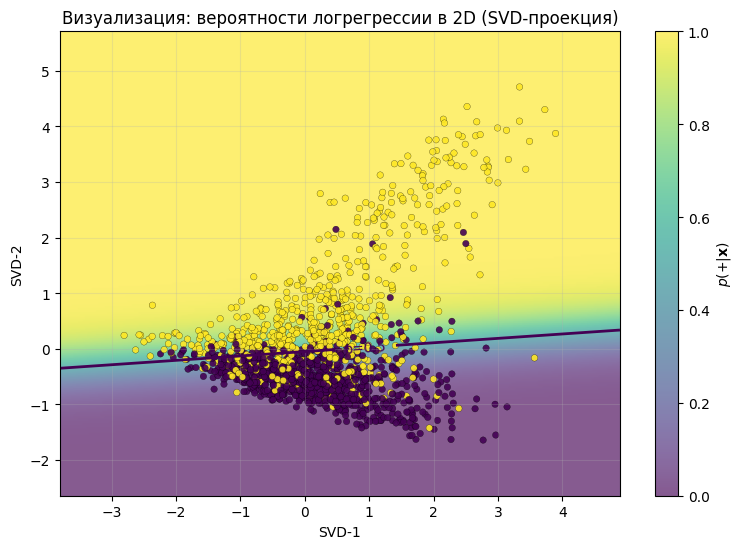

In [ ]:
# --- 2D проекция TF-IDF -> SVD ---
svd = TruncatedSVD(n_components=2, random_state=7)
Xtr_2d = svd.fit_transform(Xtr)
Xva_2d = svd.transform(Xva)

# Небольшая стандартизация помогает для красивых границ
sc = StandardScaler()
Xtr_2d = sc.fit_transform(Xtr_2d)
Xva_2d = sc.transform(Xva_2d)

lr_2d = SGDClassifier(loss="log_loss", penalty="l2", alpha=best_alpha,
                     learning_rate="constant", eta0=0.02, max_iter=2000,
                     tol=1e-6, random_state=7)
lr_2d.fit(Xtr_2d, y_train)

# --- сетка для heatmap ---
x_min, x_max = Xva_2d[:, 0].min() - 1.0, Xva_2d[:, 0].max() + 1.0
y_min, y_max = Xva_2d[:, 1].min() - 1.0, Xva_2d[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]

proba = lr_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(7.8, 5.6))
im = plt.imshow(
    proba, origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    aspect="auto", alpha=0.65,
    vmin=0.0, vmax=1.0
)
plt.colorbar(im, label=r"$p(+|\mathbf{x})$")

# граница p=0.5
cs = plt.contour(xx, yy, proba, levels=[0.5], linewidths=2)
plt.clabel(cs, fmt={0.5: "p=0.5"})

# точки валидации
plt.scatter(Xva_2d[:, 0], Xva_2d[:, 1], c=y_val, s=22, edgecolors="black", linewidths=0.2, alpha=0.9)

plt.title("Визуализация: вероятности логрегрессии в 2D (SVD-проекция)")
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


Линейный SVM (подбор C), сравнить метрики.

In [ ]:
from sklearn.svm import LinearSVC

Cs = [0.01, 0.1, 1, 3, 10, 30, 100]
svm_results = []

for C in Cs:
    svm = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            max_df=0.9,
            ngram_range=(1, 2),
        )),
        ("clf", LinearSVC(C=C, random_state=7))
    ])

    svm.fit(X_train, y_train)
    y_val_pred = svm.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")
    svm_results.append((C, acc, f1))

best_C, best_acc, best_f1 = sorted(svm_results, key=lambda x: x[2], reverse=True)[0]

print("SVM результаты (C, acc_val, f1_val):")
for C, acc, f1 in svm_results:
    print(f"C={C:<6g}  acc_val={acc:.3f}  f1_val={f1:.3f}")

print("\nЛучший C:", best_C, "| acc_val:", best_acc, "| f1_val:", best_f1)

# финальная модель (обучаем на train и проверяем на test)
best_svm = Pipeline([
    ("vec", TfidfVectorizer(
        tokenizer=tokenize_lemmas,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        max_df=0.9,
        ngram_range=(1, 2),
    )),
    ("clf", LinearSVC(C=best_C, random_state=7))
])

best_svm.fit(X_train, y_train)

SVM результаты (C, acc_val, f1_val):
C=0.01    acc_val=0.886  f1_val=0.881
C=0.1     acc_val=0.905  f1_val=0.902
C=1       acc_val=0.905  f1_val=0.903
C=3       acc_val=0.901  f1_val=0.899
C=10      acc_val=0.900  f1_val=0.898
C=30      acc_val=0.898  f1_val=0.896
C=100     acc_val=0.898  f1_val=0.896

Лучший C: 1 | acc_val: 0.9048751486325802 | f1_val: 0.9027959176597048


Pipeline(steps=[('vec',
                 TfidfVectorizer(lowercase=False, max_df=0.9, min_df=3,
                                 ngram_range=(1, 2), token_pattern=None,
                                 tokenizer=<function tokenize_lemmas at 0x79c63fe6d620>)),
                ('clf', LinearSVC(C=1, random_state=7))])

In [ ]:
# --- Оценка на val/test для лучшей модели ---
y_val_pred = best_svm.predict(X_val)
y_test_pred = best_svm.predict(X_test)

print("VAL accuracy:", accuracy_score(y_val, y_val_pred))
print("VAL macro-F1:", f1_score(y_val, y_val_pred, average="macro"))
print()
print("TEST accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST macro-F1:", f1_score(y_test, y_test_pred, average="macro"))
print("\nОтчёт (test):\n", classification_report(y_test, y_test_pred, target_names=["conflicts", "society"]))

acc_test = accuracy_score(y_test, y_test_pred)
f1_test  = f1_score(y_test, y_test_pred, average="macro")
conclusion.append({
    "Model": "LinearSVC (best_svm)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})

VAL accuracy: 0.9048751486325802
VAL macro-F1: 0.9027959176597048

TEST accuracy: 0.9013666072489602
TEST macro-F1: 0.8989740392737708

Отчёт (test):
               precision    recall  f1-score   support

   conflicts       0.89      0.94      0.91       942
     society       0.92      0.85      0.88       741

    accuracy                           0.90      1683
   macro avg       0.90      0.90      0.90      1683
weighted avg       0.90      0.90      0.90      1683



Добавить L1-регуляризацию и вывести топ‑признаки (слова/n‑граммы) для 2–3 классов.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

models_by_alpha = {}   # alpha -> обученная модель (Pipeline)
results_l1 = []        # (alpha, acc, f1, sparsity)

for a in alphas:
    model = Pipeline([
        ("vec", TfidfVectorizer(
            tokenizer=tokenize_lemmas,
            token_pattern=None,
            lowercase=False,
            min_df=3,
            max_df=0.9,
            ngram_range=(1, 2),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l1",
            alpha=a,
            learning_rate="constant",
            eta0=0.02,
            max_iter=50,
            tol=1e-6,
            random_state=7
        ))
    ])

    model.fit(X_train, y_train)
    models_by_alpha[a] = model  # сохраняем модель

    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")

    coef = model.named_steps["clf"].coef_.ravel()
    sparsity = (coef == 0).mean()

    results_l1.append((a, acc, f1, sparsity))

print("alpha       acc_val   f1_val   sparsity")
for a, acc, f1, sp in results_l1:
    print(f"{a:<10g} {acc:>7.3f} {f1:>8.3f} {sp:>10.3f}")

# лучший по F1
best_alpha = max(results_l1, key=lambda x: x[2])[0]
best_l1 = models_by_alpha[best_alpha]
print("\nЛучший alpha по F1:", best_alpha)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


alpha       acc_val   f1_val   sparsity
1e-06        0.910    0.907      0.054
1e-05        0.910    0.907      0.631
0.0001       0.902    0.899      0.982
0.001        0.796    0.778      0.999
0.01         0.560    0.359      1.000

Лучший alpha по F1: 1e-06


In [ ]:
best_balanced_alpha_l1, best_balanced_acc_l1, best_balanced_f1_l1, best_balanced_sp_l1 = results_l1[2]
best_balanced_l1 = models_by_alpha[best_balanced_alpha_l1]
print("\nСбалансированный alpha по F1:", best_balanced_alpha_l1, "| f1_val:", best_balanced_f1_l1, "| sparsity:", best_balanced_sp_l1)


Сбалансированный alpha по F1: 0.0001 | f1_val: 0.8991678156659928 | sparsity: 0.9821579584459516


In [ ]:
y_test_pred_l1 = best_balanced_l1.predict(X_test)
print("TEST accuracy (L1):", accuracy_score(y_test, y_test_pred_l1))
print("TEST macro-F1 (L1):", f1_score(y_test, y_test_pred_l1, average="macro"))

acc_test = accuracy_score(y_test, y_test_pred_l1)
f1_test  = f1_score(y_test, y_test_pred_l1, average="macro")

conclusion.append({
    "Model": "SGD Logistic (L1)",
    "Accuracy (test)": acc_test,
    "Macro-F1 (test)": f1_test
})


TEST accuracy (L1): 0.8954248366013072
TEST macro-F1 (L1): 0.8924697456807549


In [ ]:
# --- Важные признаки (топ-слова) ---
vec_l1 = best_balanced_l1.named_steps["vec"]
clf_l1 = best_balanced_l1.named_steps["clf"]

feature_names = np.array(vec_l1.get_feature_names_out())
coef = clf_l1.coef_.ravel()  # shape (n_features,)

# Сколько весов стало ровно 0?
zero_frac = (coef == 0).mean()
print(f"Доля нулевых весов (sparsity): {zero_frac:.3f}")

top_k = 20

pos_idx = np.argsort(coef)[-top_k:][::-1]
neg_idx = np.argsort(coef)[:top_k]

print("\nТоп признаков, которые увеличивают p(y=1):")
for w, c in zip(feature_names[pos_idx], coef[pos_idx]):
    print(f"{w:>20s}  {c: .3f}")

print("\nТоп признаков, которые увеличивают p(y=0):")
for w, c in zip(feature_names[neg_idx], coef[neg_idx]):
    print(f"{w:>20s}  {c: .3f}")


Доля нулевых весов (sparsity): 0.982

Топ признаков, которые увеличивают p(y=1):
             процент   6.746
         коронавирус   6.478
            квартира   5.132
               жильё   4.967
                 дом   4.119
        недвижимость   3.924
           россиянин   3.586
             вакцина   3.381
               город   2.829
                 это   2.741
            отметить   2.594
       строительство   2.575
              тысяча   2.515
              случай   2.490
               право   2.399
                цена   2.280
             ипотека   2.213
               семья   2.189
              москва   2.100
            инфекция   2.022

Топ признаков, которые увеличивают p(y=0):
           задержать  -5.894
             военный  -5.238
            убийство  -4.617
              ракета  -4.583
              летний  -4.089
            сообщить  -3.934
             полиция  -3.626
                 фсб  -3.589
         подозревать  -3.573
              оружие  -3.552
     

In [ ]:
import pandas as pd

df_final = pd.DataFrame(conclusion)
df_final = df_final.sort_values("Macro-F1 (test)", ascending=False).reset_index(drop=True)

df_final

,Model,Accuracy (test),Macro-F1 (test)
0,LinearSVC (best_svm),0.901367,0.898974
1,"SGD Logistic (Pipeline, L2)",0.897802,0.895081
2,"SGD Logistic (partial_fit, L2)",0.897802,0.895081
3,SGD Logistic (L1),0.895425,0.892470


# Заключение
Модель LinearSVC показала наилучшие результаты на тестовом наборе данных, достигнув точности 0,901 и показателя Macro-F1 0,899. Модели логистической регрессии (SGD с L1 и L2) также продемонстрировали очень высокое качество, лишь немного уступая SVM. Различия между вариантами настройки были минимальными, но L2 показал несколько более стабильные результаты.